## Pertanyaan Bisnis Arthaplan
1. Seberapa akurat model ArthaPlan dalam memprediksi pengguna akan overbudget dalam 7 hari ke depan dengan tingkat akurasi minimal 80% dalam 2 bulan pengujian?
2. Bagaimana ArthaPlan dapat mengelompokkan pengguna ke dalam kategori (hemat, normal, boros) dengan akurasi minimal 85% dalam 1 bulan menggunakan data transaksi?

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

# Load Data

In [2]:
data=pd.read_csv("cards_data.csv")
data

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6141,5361,185,Amex,Credit,300609782832003,01/2024,663,YES,1,$6900,11/2000,2013,No
6142,2711,185,Visa,Credit,4718517475996018,01/2021,492,YES,2,$5700,04/2012,2012,No
6143,1305,1007,Mastercard,Credit,5929512204765914,08/2020,237,NO,2,$9200,02/2012,2012,No
6144,743,1110,Mastercard,Debit,5589768928167462,01/2020,630,YES,1,$28074,01/2020,2020,No


# Cleaning Data

In [3]:
data['credit_limit'] = data['credit_limit'].replace('[\$,]', '', regex=True).astype(float)

kurs = 16000  # sesuaikan jika perlu

# Pastikan kolom ada
if 'credit_limit' in data.columns:
    data['credit_limit_rupiah'] = data['credit_limit'] * kurs
else:
    print("⚠️ Kolom 'credit_limit' tidak ditemukan")

print("\nPreview data:")
print(data[['credit_limit', 'credit_limit_rupiah']].head())


Preview data:
   credit_limit  credit_limit_rupiah
0       24295.0          388720000.0
1       21968.0          351488000.0
2       46414.0          742624000.0
3       12400.0          198400000.0
4          28.0             448000.0


In [4]:
data.isnull().sum()


,0
id,0
client_id,0
card_brand,0
card_type,0
card_number,0
expires,0
cvv,0
has_chip,0
num_cards_issued,0
credit_limit,0


# Feature Engineering

In [8]:
user_spending = data.groupby('client_id')['credit_limit'].sum().reset_index()
user_spending.columns = ['client_id', 'total_spending']

# ======================
# FREKUENSI TRANSAKSI
# ======================
user_freq = data.groupby('client_id').size().reset_index(name='transaction_count')

# ======================
# GABUNG
# ======================
user_data = pd.merge(user_spending, user_freq, on='client_id')

user_data.head()

,client_id,total_spending,transaction_count
0,0,105656.0,4
1,1,41805.0,3
2,2,50361.0,5
3,3,13722.0,4
4,4,136202.0,5


# EDA

## Distribusi Pengeluaran

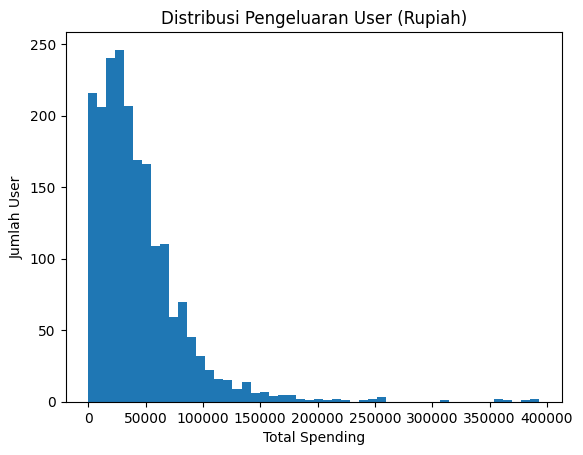

In [9]:
import matplotlib.pyplot as plt

plt.hist(user_data['total_spending'], bins=50)
plt.title("Distribusi Pengeluaran User (Rupiah)")
plt.xlabel("Total Spending")
plt.ylabel("Jumlah User")
plt.show()


## Korelasi

In [10]:
print(user_data.corr())


                   client_id  total_spending  transaction_count
client_id           1.000000        0.013278          -0.014828
total_spending      0.013278        1.000000           0.649814
transaction_count  -0.014828        0.649814           1.000000


## Top big Spenders

In [11]:
top_users = user_data.sort_values(by='total_spending', ascending=False).head(10)
print(top_users)


      client_id  total_spending  transaction_count
278         278        393197.0                  5
944         944        390933.0                  6
1259       1259        381413.0                  6
1811       1811        368894.0                  8
1156       1156        360766.0                  5
708         708        356324.0                  4
704         704        311509.0                  6
1648       1648        258595.0                  5
811         811        255981.0                  7
797         797        253066.0                  9


# Visualization

## spending vs frequency

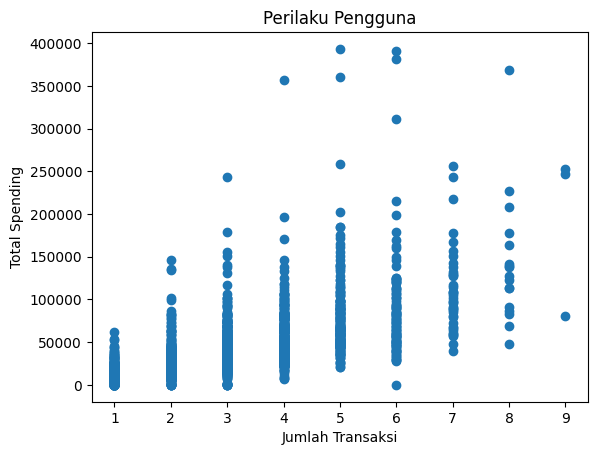

In [12]:
plt.scatter(user_data['transaction_count'], user_data['total_spending'])
plt.xlabel("Jumlah Transaksi")
plt.ylabel("Total Spending")
plt.title("Perilaku Pengguna")
plt.show()


# Segmentasi User

## Pertanyaan 2

In [13]:
# Kategori berdasarkan quantile
q1 = user_data['total_spending'].quantile(0.33)
q2 = user_data['total_spending'].quantile(0.66)

def kategori(x):
    if x < q1:
        return "Hemat"
    elif x < q2:
        return "Normal"
    else:
        return "Boros"

user_data['kategori'] = user_data['total_spending'].apply(kategori)

print(user_data.head())


   client_id  total_spending  transaction_count kategori
0          0        105656.0                  4    Boros
1          1         41805.0                  3   Normal
2          2         50361.0                  5    Boros
3          3         13722.0                  4    Hemat
4          4        136202.0                  5    Boros


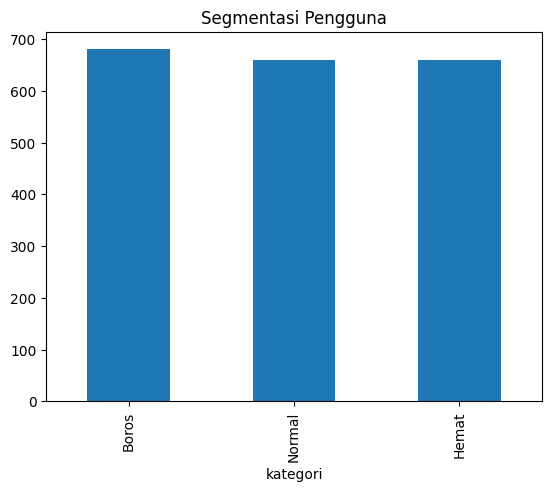

In [14]:
user_data['kategori'].value_counts().plot(kind='bar')
plt.title("Segmentasi Pengguna")
plt.show()


In [16]:
# Rata-rata user
avg_spending = user_data['total_spending'].mean()

# threshold
threshold = avg_spending * 1.2

user_data['overbudget'] = user_data['total_spending'] > threshold

print(user_data[['client_id', 'total_spending', 'overbudget']].head())


   client_id  total_spending  overbudget
0          0        105656.0        True
1          1         41805.0       False
2          2         50361.0       False
3          3         13722.0       False
4          4        136202.0        True


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = user_data[['total_spending', 'transaction_count']]
y = user_data['overbudget']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Akurasi model:", acc)


Akurasi model: 1.0


In [19]:
main_data = pd.merge(data, user_data, on='client_id')

In [20]:
main_data.to_csv('main_data.csv', index=False)